# 05. OpenCV로 가위바위보 판정기 만들기 (실습)

이 실습은 `src/opencv/rps_classic/`에 이미 구현된 가위바위보 판정 파이프라인을
**직접 재구현**해봅니다. 01강(OpenCV 입문)과 04강(3자 비교)에서 이미 본 내용을
"왜 이렇게 짰는지" 이해하고 나서, 그 로직을 스스로 채워 넣는 것이 이 실습의 목표입니다.

## 학습 목표
- YCrCb 색공간으로 피부색 마스크를 만들 수 있다.
- Convexity Defects(볼록 껍질 결함)로 손가락 사이 골을 찾을 수 있다.
- 골 개수 + solidity로 편 손가락 개수를 추정할 수 있다.
- 왜 이 전통 기법이 실사진 6장 중 2장만 맞히는지(2/6) 직접 확인하고 한계를 설명할 수 있다.

## 이 실습에서 재구현할 파이프라인

```
BGR 프레임 → YCrCb 변환 → inRange(피부색) → 모폴로지(open/close) → 피부 마스크
   → 최대 컨투어 → 볼록 껍질 결함(convexity defects) → 깊이·각도 필터 → 골 개수
   → 골 개수 + solidity → 편 손가락 개수 → 가위/바위/보 분류 → 승패 판정
```

> 빈칸은 `_____` 로 표시돼 있고, 바로 위/옆의 `# [TODO]` 주석이 힌트입니다.
> 원본 구현은 `src/opencv/rps_classic/rps_classic/`에 있습니다 — 막히면 참고하세요.

In [1]:
%pip install -q opencv-python


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: /opt/homebrew/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
import math
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import font_manager

# 그래프의 한글 라벨이 네모(□)로 깨지지 않도록 한글 폰트를 지정한다.
_installed = {f.name for f in font_manager.fontManager.ttflist}
for _font in ("AppleGothic", "Malgun Gothic", "NanumGothic"):
    if _font in _installed:
        plt.rcParams["font.family"] = _font
        break
plt.rcParams["axes.unicode_minus"] = False


def find_workshop_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / "src" / "yolo" / "rps").is_dir():
            return candidate
    raise FileNotFoundError("워크샵 루트를 찾지 못했습니다")


WORKSHOP = find_workshop_root(Path.cwd())
FIXTURE_DIR = WORKSHOP / "src" / "yolo" / "rps" / "tests" / "fixtures"

# 3자 비교(04강)와 동일한 6장 실사진 픽스처 — OpenCV/YOLO/MediaPipe가 공유한다.
FIXTURES = ["rock_0", "rock_1", "paper_0", "paper_1", "scissors_0", "scissors_1"]
TRUTH = {
    "rock_0": "ROCK", "rock_1": "ROCK",
    "paper_0": "PAPER", "paper_1": "PAPER",
    "scissors_0": "SCISSORS", "scissors_1": "SCISSORS",
}

images = {name: cv2.imread(str(FIXTURE_DIR / f"{name}.png")) for name in FIXTURES}
print({name: img.shape for name, img in images.items()})

{'rock_0': (300, 300, 3), 'rock_1': (300, 300, 3), 'paper_0': (300, 300, 3), 'paper_1': (300, 300, 3), 'scissors_0': (300, 300, 3), 'scissors_1': (300, 300, 3)}


## 1. 피부색 마스크 — 왜 YCrCb인가

01강에서 배운 HSV 대신 **YCrCb**를 씁니다. YCrCb는 밝기(Y)와 색차(Cr, Cb)가
직교하도록 설계된 색공간이라, 조명이 바뀌어도 Cr/Cb는 상대적으로 덜 흔들립니다.
Y축을 아예 임계 범위에서 빼면(`[0, 255]` 전체 허용) 밝기 변화를 설계 수준에서 무시할 수 있습니다.

임계값 `Cr∈[133,173], Cb∈[77,127]`은 Chai & Ngan(1999)의 고전적 피부색 문헌값입니다.

In [3]:
SKIN_LOWER_YCRCB = (0, 133, 77)
SKIN_UPPER_YCRCB = (255, 173, 127)


def skin_mask(frame_bgr, *, kernel_size: int = 5) -> np.ndarray:
    """BGR 프레임에서 피부색 이진 마스크(0/255, uint8)를 만든다."""
    frame_bgr = cv2.GaussianBlur(frame_bgr, (5, 5), 0)
    lower = np.array(SKIN_LOWER_YCRCB, dtype=np.uint8)
    upper = np.array(SKIN_UPPER_YCRCB, dtype=np.uint8)

    ycrcb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2YCrCb)  # [TODO] BGR을 YCrCb로 변환 — cv2.cvtColor
    mask = cv2.inRange(ycrcb, lower, upper)  # [TODO] Cr/Cb 범위 안의 픽셀만 골라 이진 마스크 생성 — cv2.inRange

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)  # [TODO] 배경의 작은 흰 점(노이즈) 제거 — cv2.MORPH_OPEN(침식→팽창)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)  # [TODO] 손 안쪽 작은 구멍 메우기 — cv2.MORPH_CLOSE(팽창→침식)
    return mask

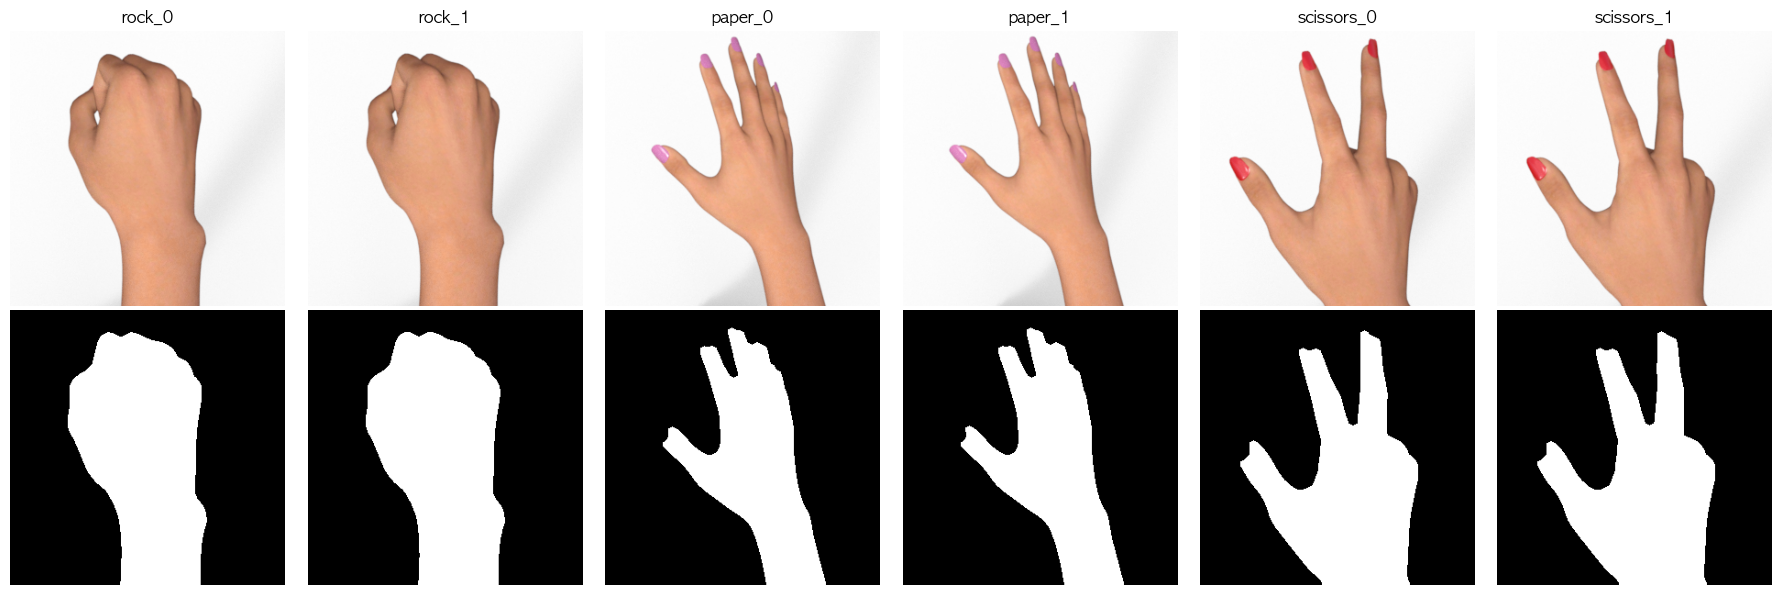

In [4]:
fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for i, name in enumerate(FIXTURES):
    mask = skin_mask(images[name])
    axes[0, i].imshow(cv2.cvtColor(images[name], cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(name)
    axes[0, i].axis("off")
    axes[1, i].imshow(mask, cmap="gray")
    axes[1, i].axis("off")
plt.tight_layout()
plt.show()

## 2. 최대 컨투어 찾기

마스크에서 가장 넓은 외곽 컨투어를 손으로 간주합니다. `RETR_EXTERNAL`로 내부 구멍은
무시하고, `CHAIN_APPROX_NONE`으로 모든 윤곽 점을 보존합니다(다음 단계의 convexity
defects가 직선 구간이 압축되면 골 깊이를 과소평가하기 때문입니다).

In [5]:
MIN_CONTOUR_AREA = 3000


def largest_contour(mask, *, min_area: float = MIN_CONTOUR_AREA):
    """마스크에서 넓이가 가장 큰 외곽 컨투어를 반환한다. 없으면 None."""
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return None
    contour = max(contours, key=cv2.contourArea)  # [TODO] 넓이가 가장 큰 컨투어 선택
    if cv2.contourArea(contour) < min_area:
        return None
    return contour

## 3. Convexity Defects — 손가락 사이 골 찾기

편 손가락의 끝점은 볼록 껍질(convex hull) 위에 놓이고, 손가락 사이의 골은 껍질
안쪽으로 파여 있습니다. `far` 지점에서 두 손가락 끝(`start`, `end`)을 바라본
사잇각을 **코사인 법칙**으로 구해, 90도 이하만 "손가락 사이 골"로 인정합니다.

$$\cos\theta = \frac{b^2 + c^2 - a^2}{2bc}$$

여기서 `a`는 `start`-`end` 거리(far의 맞은편 변), `b`는 `start`-`far` 거리, `c`는 `end`-`far` 거리입니다.

In [6]:
def defect_angle_deg(start, end, far) -> float:
    """far 지점에서 start-end를 바라본 사잇각(도). 정의 불가하면 180.0(둔각 취급)."""
    sx, sy = float(start[0]), float(start[1])
    ex, ey = float(end[0]), float(end[1])
    fx, fy = float(far[0]), float(far[1])

    a = math.hypot(sx - ex, sy - ey)  # far의 맞은편 변
    b = math.hypot(sx - fx, sy - fy)
    c = math.hypot(ex - fx, ey - fy)

    if b == 0.0 or c == 0.0:
        return 180.0

    cos_theta = max(-1.0, min(1.0, (b * b + c * c - a * a) / (2 * b * c)))  # [TODO] 코사인 법칙
    return math.degrees(math.acos(cos_theta))  # [TODO] 라디안을 도(degree)로 변환


# 검증: far=(0,0)이 직각 꼭짓점인 3-4-5 직각삼각형 → 90도가 나와야 한다
assert abs(defect_angle_deg((3, 0), (0, 4), (0, 0)) - 90.0) < 0.01
print("defect_angle_deg 검증 통과 — 직각삼각형에서 90.0도")

defect_angle_deg 검증 통과 — 직각삼각형에서 90.0도


In [7]:
MIN_DEFECT_DEPTH = 10.0
MAX_DEFECT_ANGLE_DEG = 90.0


def convexity_defects(contour) -> np.ndarray:
    """(N, 4) 배열 [start_idx, end_idx, far_idx, depth_x256]을 반환한다."""
    empty = np.empty((0, 4), dtype=np.int32)
    if contour is None or len(contour) < 4:
        return empty
    hull_indices = cv2.convexHull(contour, returnPoints=False)
    if hull_indices is None or len(hull_indices) < 3:
        return empty
    try:
        defects = cv2.convexityDefects(contour, hull_indices)
    except cv2.error:
        return empty
    if defects is None:
        return empty
    return defects.reshape(-1, 4)


def count_finger_gaps(contour, defects, *, min_depth=MIN_DEFECT_DEPTH, max_angle_deg=MAX_DEFECT_ANGLE_DEG) -> int:
    """깊이·각도 필터를 통과한 결함(=손가락 사이 골) 개수."""
    gaps = 0
    for s_idx, e_idx, f_idx, depth_fixed in defects:
        if depth_fixed / 256.0 < min_depth:  # [TODO] OpenCV는 깊이를 256배 고정소수점 정수로 준다 — 256으로 나눠야 픽셀 단위
            continue
        start = contour[s_idx][0]
        end = contour[e_idx][0]
        far = contour[f_idx][0]
        if defect_angle_deg(start, end, far) <= max_angle_deg:  # [TODO] 90도 이하만 손가락 사이 골로 인정
            gaps += 1
    return gaps

## 4. 0개 골의 모호성 — solidity로 가르기

"손가락 N개 → 골 N-1개"는 N≥2에서만 성립합니다. 주먹(N=0)과 검지만 편 경우(N=1)는
**둘 다 골이 0개**라 결함 정보만으로 구분할 수 없습니다. 그래서 solidity(컨투어 넓이
/ 볼록 껍질 넓이)를 추가 단서로 씁니다 — 주먹은 껍질을 거의 꽉 채우고(1에 가까움),
손가락이 하나라도 튀어나오면 껍질에 빈 삼각형이 생겨 값이 떨어집니다.

픽스처 실측: 주먹 0.895 / 보 0.735 / 가위 0.699 → 임계값 0.80이 그 사이를 가릅니다.

In [8]:
FIST_SOLIDITY = 0.80


def count_extended_fingers(gaps: int, solidity: float, *, fist_solidity: float = FIST_SOLIDITY) -> int:
    """골 개수 + solidity로 편 손가락 개수를 추정한다."""
    if gaps > 0:
        return gaps + 1  # [TODO] N개 골 = N+1개 손가락
    return 0 if solidity >= fist_solidity else 1  # [TODO] 골이 0개면 solidity로 주먹(0)/검지만(1) 구분


def analyze_contour(contour):
    area = float(cv2.contourArea(contour))
    hull_points = cv2.convexHull(contour)
    hull_area = float(cv2.contourArea(hull_points))
    solidity = area / hull_area if hull_area > 0 else 0.0
    gaps = count_finger_gaps(contour, convexity_defects(contour))
    fingers = count_extended_fingers(gaps, solidity)
    return {"area": area, "solidity": solidity, "gaps": gaps, "fingers": fingers}

## 5. 승패 판정

편 손가락 개수 → 손모양(0=바위/2=가위/5=보) → 승패 규칙(가위>보>바위>가위)은
결정적 규칙이므로 모델 없이 if/dict로 충분합니다.

In [9]:
_BEATS = {"ROCK": "SCISSORS", "PAPER": "ROCK", "SCISSORS": "PAPER"}


def fingers_to_gesture(fingers: int) -> str:
    if fingers == 0:
        return "ROCK"
    if fingers == 2:
        return "SCISSORS"
    if fingers == 5:
        return "PAPER"
    return "UNKNOWN"


def judge(player: str, ai: str) -> str:
    """플레이어 관점 승패. 어느 한쪽이라도 UNKNOWN이면 UNDECIDABLE."""
    if player == "UNKNOWN" or ai == "UNKNOWN":
        return "UNDECIDABLE"  # [TODO] 인식 실패를 무승부로 뭉개면 실패율이 통계에서 사라진다
    if player == ai:
        return "DRAW"
    if _BEATS[player] == ai:  # [TODO] player가 ai를 이기는 조합인지 확인
        return "WIN"
    return "LOSE"

## 6. 종합 — 6장 실사진으로 정확도 측정

지금까지 채운 함수들을 이어 붙여 전체 파이프라인을 완성하고, 04강에서 본 것과
같은 6장 실사진에 돌려봅니다. **2/6 근처가 나오면 정상입니다** — 이건 버그가 아니라
전통 기법(피부색+볼록껍질)의 실제 한계입니다. 이유는 아래 7절에서 확인합니다.

In [10]:
correct = 0
predictions = {}
for name in FIXTURES:
    mask = skin_mask(images[name])
    contour = largest_contour(mask)
    if contour is None:
        predicted = "UNKNOWN"
    else:
        result = analyze_contour(contour)
        predicted = fingers_to_gesture(result["fingers"])
    predictions[name] = predicted
    is_correct = predicted == TRUTH[name]
    correct += is_correct
    print(f"{name:12s} 정답={TRUTH[name]:9s} 예측={predicted:9s} {'O' if is_correct else 'X'}")

print(f"\n정확도: {correct}/{len(FIXTURES)}")

rock_0       정답=ROCK      예측=ROCK      O
rock_1       정답=ROCK      예측=ROCK      O
paper_0      정답=PAPER     예측=UNKNOWN   X
paper_1      정답=PAPER     예측=UNKNOWN   X
scissors_0   정답=SCISSORS  예측=UNKNOWN   X
scissors_1   정답=SCISSORS  예측=UNKNOWN   X

정확도: 2/6


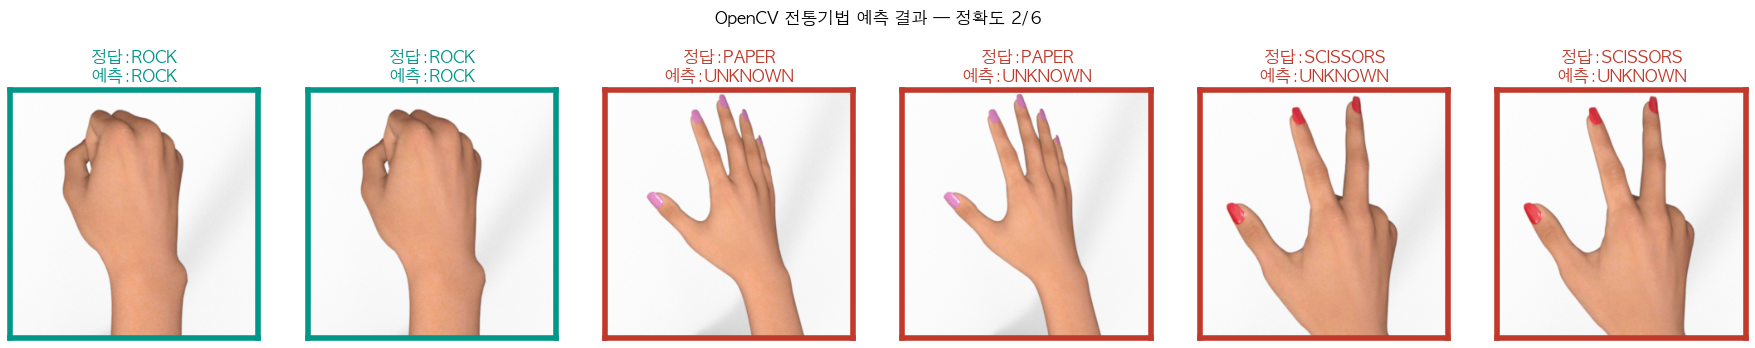

In [11]:
fig, axes = plt.subplots(1, 6, figsize=(18, 3.5))
for ax, name in zip(axes, FIXTURES):
    ok = predictions[name] == TRUTH[name]
    ax.imshow(cv2.cvtColor(images[name], cv2.COLOR_BGR2RGB))
    ax.set_title(f"정답:{TRUTH[name]}\n예측:{predictions[name]}", color="#009688" if ok else "#c0392b")
    for spine in ax.spines.values():
        spine.set_edgecolor("#009688" if ok else "#c0392b")
        spine.set_linewidth(4)
    ax.set_xticks([]); ax.set_yticks([])
plt.suptitle(f"OpenCV 전통기법 예측 결과 — 정확도 {correct}/{len(FIXTURES)}")
plt.tight_layout(rect=(0, 0, 1, 0.90))
plt.show()

## 7. 왜 가위(SCISSORS)는 원리적으로 못 맞히는가

가위 실패의 원인은 완화 불가능합니다: 골 검출 자체는 정확한데(골 2개), **어느
골이 엄지 쪽인지 알 정보가 없어서** "골 2개=가위"라는 규칙이 엄지를 편 다른
포즈와 구분되지 않습니다. MediaPipe가 21개 랜드마크로 엄지(인덱스 4)를 **이름으로
지목**할 수 있는 것과 정확히 대비되는 지점입니다 — 07강에서 직접 확인합니다.

---

## AI Pair 섹션

### 1️⃣ Solo — 직접 해보기
`MIN_CONTOUR_AREA`, `FIST_SOLIDITY` 값을 바꿔가며 정확도가 어떻게 달라지는지
실험해보세요. 6/6이 나오는 조합을 찾을 수 있나요? (원본 프로젝트는 224개 조합을
전수 탐색해도 6/6이 안 나온다는 것을 이미 확인했습니다 — 왜 그런지 위 7절을
다시 읽어보세요.)

### 2️⃣ Review — AI에게 리뷰 받기
아래 프롬프트를 ChatGPT/Claude에 그대로 복사해서 물어보세요:

> "OpenCV로 손 모양을 인식할 때 YCrCb 색공간의 피부색 마스크와 convexity
> defects(볼록 껍질 결함)를 쓰는 방법의 근본적인 한계가 뭐야? 딥러닝 기반
> 방법(MediaPipe, YOLO)과 비교해서 설명해줘."

### 3️⃣ Debug — 틀린 코드 고치기
아래 코드는 실행되지만 결과가 이상합니다. 어디가 문제인지 찾아 고쳐보세요.

In [12]:
# 이 코드는 에러 없이 실행되지만 모든 결함의 깊이가 너무 작게 측정됩니다.
def count_finger_gaps_buggy(contour, defects, *, min_depth=10.0, max_angle_deg=90.0):
    gaps = 0
    for s_idx, e_idx, f_idx, depth_fixed in defects:
        if depth_fixed < min_depth:  # 힌트: OpenCV가 깊이를 어떤 단위로 반환했는지 위 3절을 다시 보세요
            continue
        start, end, far = contour[s_idx][0], contour[e_idx][0], contour[f_idx][0]
        if defect_angle_deg(start, end, far) <= max_angle_deg:
            gaps += 1
    return gaps

### 4️⃣ Prompt Card — 더 탐구해보기
- "convexity defects 대신 손가락 개수를 세는 다른 전통 컴퓨터 비전 기법이 있을까?"
- "solidity 임계값 0.80을 다른 손 크기·다른 카메라 각도에서도 쓸 수 있게 하려면 어떻게 일반화할까?"
- "이 파이프라인을 실시간 웹캠에 적용하면 프레임마다 몇 ms가 걸릴지 어떻게 측정할까?"

---

## 📚 세션 요약

**🎯 핵심 Takeaways**
- YCrCb는 밝기(Y)와 색차(Cr/Cb)가 분리돼 있어 조명 변화에 강한 피부색 검출을 가능하게 한다.
- Convexity defects의 깊이는 256배 고정소수점 정수로 반환된다 — 256으로 나누는 것을 잊으면 흔한 버그가 된다.
- 골 개수만으로는 0개(주먹/검지만)와 가위(어느 골이 엄지 쪽인지 모름)를 원리적으로 구분할 수 없다.
- 이 한계는 파라미터 튜닝으로 해결되지 않는다 — "표현 방식 자체의 한계"이며, 딥러닝 기반 방법(YOLO/MediaPipe)이 필요한 이유를 보여준다.